In [1]:
def askQuestion(ind, disorderOffset):
    question = [random.randint(0,3),random.randint(0,3),random.randint(0,4),random.randint(0,3)]
    return question

In [2]:
anxiety_threshold = [10,9,8,6,5,3,2]
depression_threshold = [10,10,9,8,7,6,4,3,2]
stress_threshold = [23,20,17,16,15,14,12,9,6,3]

In [3]:
from gym import Env
from gym.spaces import Discrete, MultiDiscrete
import numpy as np
import random

In [4]:
class ChatBotEnv(Env):
  def __init__(self):
    self.action_space = Discrete(4)
    self.observation_space = MultiDiscrete([4,4,5,4])
    self.state = [random.randint(0,3),random.randint(0,3),random.randint(0,4),random.randint(0,3)]
    self.anxiety_question_offset = 7
    self.depression_question_offset = 9
    self.stress_question_offset = 10
    self.anxiety_score = 0
    self.depression_score = 0
    self.stress_score = 0
    self.anxiety_predicted = False
    self.depression_predicted = False
    self.stress_predicted = False

  def step(self, action):
    done = False
      
    # Ask Anxiety
    if action == 0:
        if self.anxiety_question_offset == -1:
            reward = -5
        elif self.anxiety_question_offset == 0 and self.anxiety_score >= anxiety_threshold[0]:
            self.anxiety_predicted = True
            self.anxiety_question_offset = -1
            reward = 10
        elif self.anxiety_question_offset == 7 or self.anxiety_score >= anxiety_threshold[self.anxiety_question_offset]:
            self.state = askQuestion(self.anxiety_question_offset, 0)
            self.anxiety_question_offset -= 1;
            self.anxiety_score += self.state[0]
            reward = -1
        else:
            reward = -5
    # Ask Depression
    if action == 1:
        if self.depression_question_offset == -1:
            reward = -5
        elif self.depression_question_offset == 0 and self.depression_score >= depression_threshold[0]:
            self.depression_predicted = True
            self.depression_question_offset = -1
            reward = 10
        elif self.depression_question_offset == 9 or self.depression_score >= depression_threshold[self.depression_question_offset]:
            self.state = askQuestion(self.depression_question_offset, 1)
            self.depression_question_offset -= 1;
            self.depression_score += self.state[1]
            reward = -1
        else:
            reward = -5
    # Ask Stress
    if action == 2:
        if self.stress_question_offset == -1:
            reward = -5
        elif self.stress_question_offset == 0 and self.stress_score >= stress_threshold[0]:
            self.stress_predicted = True
            self.stress_question_offset = -1
            reward = 10
        elif self.stress_question_offset == 10 or self.stress_score >= stress_threshold[self.stress_question_offset]:
            self.state = askQuestion(self.stress_question_offset, 2)
            self.stress_question_offset -= 1;
            self.stress_score += self.state[2]
            reward = -1
        else:
            reward = -5
    else:
        good_to_go = True
        if not self.anxiety_predicted:
            if self.anxiety_question_offset == 7:
                reward = -5
                good_to_go = False
            elif self.anxiety_score >= anxiety_threshold[self.anxiety_question_offset]:
                reward = -5
                good_to_go = False
        if not self.depression_predicted:
            if self.depression_question_offset == 9:
                reward = -5
                good_to_go = False
            elif self.depression_score >= depression_threshold[self.depression_question_offset]:
                reward = -5
                good_to_go = False
        if not self.stress_predicted:
            if self.stress_question_offset == 10:
                reward = -5
                good_to_go = False
            elif self.stress_score >= stress_threshold[self.stress_question_offset]:
                reward = -5
                good_to_go = False
        if good_to_go:
            done = True
            if self.anxiety_predicted:
                print("Anxiety")
            if self.depression_predicted:
                print("Depression")
            if self.stress_predicted:
                print("Stress")
            if not self.anxiety_predicted and not self.depression_predicted and not self.stress_predicted:
                print("Normal")
            reward = 20
            
    info = {}
        
    return self.state, reward, done, info

  def render(self):
    pass

  def reset(self):
    self.state = [random.randint(0,3),random.randint(0,3),random.randint(0,4),random.randint(0,3)]
    self.anxiety_question_offset = 7
    self.depression_question_offset = 9
    self.stress_question_offset = 10
    self.anxiety_score = 0
    self.depression_score = 0
    self.stress_score = 0
    self.anxiety_predicted = False
    self.depression_predicted = False
    self.stress_predicted = False
      
    return self.state

In [5]:
env = ChatBotEnv()

In [7]:
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines.common.policies import MlpLstmPolicy

In [8]:
import os

In [9]:
path = os.path.join("Training_Final","Recurrent_Model_Final")

In [10]:
rl_model = RecurrentPPO.load(path,env)

C:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [11]:
device = "cpu"

In [15]:
import gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO  # Change to your algo

episode_rewards = []
episode_lengths = []

def evaluate_and_plot(rl_model, env, n_episodes):
    print(f"\n[INFO] Starting evaluation for {n_episodes} episodes...\n")

    global episode_rewards
    global episode_lengths

    for ep in range(n_episodes):
        obs = env.reset()
        done = False
        total_reward = 0.0
        steps = 0

        while not done:
            action, _ = rl_model.predict(obs)
            obs, reward, done, info = env.step(action)
            total_reward += reward
            steps += 1

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)

        print(f"[Episode {ep+1}] Reward: {total_reward:.2f}, Length: {steps}")

    # Convert to numpy arrays
    episode_rewards = np.array(episode_rewards)
    episode_lengths = np.array(episode_lengths)

    # ---- Metrics ----
    metrics = {
        "mean_reward": np.mean(episode_rewards),
        "std_reward": np.std(episode_rewards),
        "mean_episode_length": np.mean(episode_lengths),
        "std_episode_length": np.std(episode_lengths),
        "min_reward": np.min(episode_rewards),
        "max_reward": np.max(episode_rewards)
    }

    print("\n[INFO] Evaluation Summary:")
    print(f"  Mean Reward: {metrics['mean_reward']:.2f}")
    print(f"  Std Reward: {metrics['std_reward']:.2f}")
    print(f"  Min Reward: {metrics['min_reward']:.2f}")
    print(f"  Max Reward: {metrics['max_reward']:.2f}")
    print(f"  Mean Episode Length: {metrics['mean_episode_length']:.2f}")
    print(f"  Std Episode Length: {metrics['std_episode_length']:.2f}")

metrics = evaluate_and_plot(rl_model, env, 20000)


[INFO] Starting evaluation for 20000 episodes...

Depression
[Episode 1] Reward: -51.00, Length: 16
Anxiety
[Episode 2] Reward: -81.00, Length: 22
Normal
[Episode 3] Reward: -62.00, Length: 19
Normal
[Episode 4] Reward: -32.00, Length: 13
Normal
[Episode 5] Reward: -7.00, Length: 8
Depression
[Episode 6] Reward: -96.00, Length: 25
Normal
[Episode 7] Reward: -16.00, Length: 9
Anxiety
[Episode 8] Reward: -58.00, Length: 19
Normal
[Episode 9] Reward: -27.00, Length: 12
Normal
[Episode 10] Reward: -1.00, Length: 6
Normal
[Episode 11] Reward: -104.00, Length: 29
Anxiety
[Episode 12] Reward: -76.00, Length: 21
Normal
[Episode 13] Reward: -1.00, Length: 6
Anxiety
Depression
[Episode 14] Reward: -186.00, Length: 43
Anxiety
[Episode 15] Reward: -141.00, Length: 34
Depression
[Episode 16] Reward: -76.00, Length: 21
Anxiety
[Episode 17] Reward: -191.00, Length: 44
Depression
[Episode 18] Reward: -101.00, Length: 26
Normal
[Episode 19] Reward: 14.00, Length: 3
Normal
[Episode 20] Reward: -44.00, 


[INFO] Generating plots...


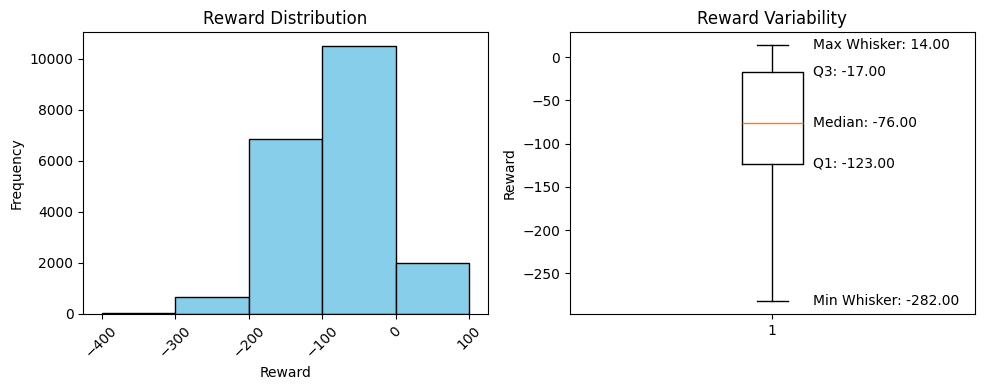

In [18]:
import numpy as np
import matplotlib.pyplot as plt

print("\n[INFO] Generating plots...")

# Define bin edges (strict 100 length, includes 0)
start_bin = (min(episode_rewards) // 100) * 100
end_bin = ((max(episode_rewards) // 100) + 1) * 100
if start_bin > 0:
    start_bin = 0  # Ensure 0 is included if min > 0
bin_edges = np.arange(start_bin, end_bin + 100, 100)

plt.figure(figsize=(10,4))

# 1. Histogram
plt.subplot(1, 2, 1)
plt.hist(episode_rewards, bins=bin_edges, color='skyblue', edgecolor='black')
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.title('Reward Distribution')
plt.xticks(bin_edges, rotation=45)

# 2. Boxplot with key values (no outliers shown)
plt.subplot(1, 2, 2)
box = plt.boxplot(episode_rewards, vert=True, showfliers=False)  # Hide outliers

# Extract values
med = box['medians'][0].get_ydata()[0]
q1 = box['boxes'][0].get_ydata()[0]
q3 = box['boxes'][0].get_ydata()[2]
whis_low = box['whiskers'][0].get_ydata()[1]
whis_high = box['whiskers'][1].get_ydata()[1]

# Annotate values
plt.text(1.1, med, f"Median: {med:.2f}", va='center')
plt.text(1.1, q1, f"Q1: {q1:.2f}", va='center')
plt.text(1.1, q3, f"Q3: {q3:.2f}", va='center')
plt.text(1.1, whis_low, f"Min Whisker: {whis_low:.2f}", va='center')
plt.text(1.1, whis_high, f"Max Whisker: {whis_high:.2f}", va='center')

plt.ylabel('Reward')
plt.title('Reward Variability')

plt.tight_layout()
plt.show()

In [19]:
import numpy as np

def evaluate_model(rl_model, env, n_episodes=100):
    episode_rewards = []
    episode_lengths = []
    success_count = 0

    for episode in range(n_episodes):
        obs = env.reset()
        done = False
        total_reward = 0.0
        steps = 0

        while not done:
            action, _ = rl_model.predict(obs)
            obs, reward, done, info = env.step(action)
            total_reward += reward
            steps += 1

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)

    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)
    mean_length = np.mean(episode_lengths)
    std_length = np.std(episode_lengths)

    return {
        "mean_reward": mean_reward,
        "std_reward": std_reward,
        "mean_episode_length": mean_length,
        "std_episode_length": std_length,
        "min_reward": np.min(episode_rewards),
        "max_reward": np.max(episode_rewards)
    }

# Example usage
metrics = evaluate_model(rl_model, env, n_episodes=100)
for key, value in metrics.items():
    print(f"{key}: {value}")

Normal
Anxiety
Normal
Normal
Normal
Normal
Depression
Anxiety
Normal
Normal
Anxiety
Depression
Normal
Anxiety
Normal
Normal
Anxiety
Depression
Anxiety
Depression
Normal
Depression
Normal
Depression
Anxiety
Depression
Normal
Anxiety
Depression
Normal
Normal
Depression
Normal
Normal
Normal
Normal
Anxiety
Normal
Normal
Normal
Depression
Anxiety
Normal
Normal
Depression
Normal
Normal
Anxiety
Stress
Depression
Stress
Anxiety
Depression
Normal
Normal
Anxiety
Normal
Depression
Anxiety
Depression
Normal
Normal
Anxiety
Normal
Normal
Anxiety
Depression
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Depression
Normal
Normal
Normal
Normal
Depression
Depression
Normal
Normal
Anxiety
Normal
Normal
Depression
Normal
Normal
Depression
Stress
Depression
Normal
Normal
Normal
Normal
Anxiety
Depression
Depression
Anxiety
Normal
mean_reward: -60.94
std_reward: 57.039603785440164
mean_episode_length: 18.67
std_episode_length: 11.563783982762734
min_r